In [1]:
import xarray as xr
import numpy as np

jcm_ds = xr.open_dataset('jcm_3year.nc')
speedy_ds = xr.open_dataset('speedy_3year_monthlyavg.nc')
speedy_clouds = xr.open_dataset('speedy_3year_clouds_precip.nc')

In [2]:
print(speedy_ds)
jcm_ds = jcm_ds.transpose('time', 'level','lat', 'lon')
jcm_ds['temperature'] = jcm_ds.temperature - 273.15
grav = 9.81
speedy_ds['t'] = speedy_ds.t - 273.15
speedy_ds['q'] = speedy_ds.q*1e3
speedy_ds['phi'] = speedy_ds.phi * grav # speedy outputs phi in m, instead of m^2/s^2
speedy_ds['ps'] = speedy_ds.ps / 100000

<xarray.Dataset> Size: 33MB
Dimensions:  (time: 37, lev: 8, lat: 48, lon: 96)
Coordinates:
  * time     (time) datetime64[ns] 296B 1982-01-01 1982-01-31 ... 1984-12-16
  * lev      (lev) float32 32B 0.025 0.095 0.2 0.34 0.51 0.685 0.835 0.95
  * lat      (lat) float32 192B -87.22 -83.51 -79.79 ... 79.79 83.51 87.22
  * lon      (lon) float32 384B 0.0 3.75 7.5 11.25 ... 345.0 348.8 352.5 356.2
Data variables:
    u        (time, lev, lat, lon) float32 5MB ...
    v        (time, lev, lat, lon) float32 5MB ...
    t        (time, lev, lat, lon) float32 5MB ...
    q        (time, lev, lat, lon) float32 5MB ...
    rh       (time, lev, lat, lon) float32 5MB ...
    phi      (time, lev, lat, lon) float32 5MB ...
    ps       (time, lat, lon) float32 682kB ...


In [3]:
speedy_clouds.time

<xarray.DataArray 'time' (time: 37)> Size: 296B
array(['1982-01-01T00:00:00.000000000', '1982-01-31T00:00:00.000000000',
       '1982-03-02T00:00:00.000000000', '1982-04-01T00:00:00.000000000',
       '1982-05-01T00:00:00.000000000', '1982-05-31T00:00:00.000000000',
       '1982-06-30T00:00:00.000000000', '1982-07-30T00:00:00.000000000',
       '1982-08-29T00:00:00.000000000', '1982-09-28T00:00:00.000000000',
       '1982-10-28T00:00:00.000000000', '1982-11-27T00:00:00.000000000',
       '1982-12-27T00:00:00.000000000', '1983-01-26T00:00:00.000000000',
       '1983-02-25T00:00:00.000000000', '1983-03-27T00:00:00.000000000',
       '1983-04-26T00:00:00.000000000', '1983-05-26T00:00:00.000000000',
       '1983-06-25T00:00:00.000000000', '1983-07-25T00:00:00.000000000',
       '1983-08-24T00:00:00.000000000', '1983-09-23T00:00:00.000000000',
       '1983-10-23T00:00:00.000000000', '1983-11-22T00:00:00.000000000',
       '1983-12-22T00:00:00.000000000', '1984-01-21T00:00:00.000000000',
       '1984-02-20T00:00:00.000000000', '1984-03-21T00:00:00.000000000',
       '1984-04-20T00:00:00.000000000', '1984-05-20T00:00:00.000000000',
       '1984-06-19T00:00:00.000000000', '1984-07-19T00:00:00.000000000',
       '1984-08-18T00:00:00.000000000', '1984-09-17T00:00:00.000000000',
       '1984-10-17T00:00:00.000000000', '1984-11-16T00:00:00.000000000',
       '1984-12-16T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 296B 1982-01-01 1982-01-31 ... 1984-12-16

In [4]:
speedy_ds = speedy_ds.rename({'lev':'level'})
speedy_ds = speedy_ds.isel(level=slice(None, None, -1)) # reverse levels
speed_clouds = speedy_clouds.rename({'lev':'level'})
speed_clouds = speed_clouds.isel(level=slice(None, None, -1)) # reverse levels

In [5]:
speedy_clouds.time

<xarray.DataArray 'time' (time: 37)> Size: 296B
array(['1982-01-01T00:00:00.000000000', '1982-01-31T00:00:00.000000000',
       '1982-03-02T00:00:00.000000000', '1982-04-01T00:00:00.000000000',
       '1982-05-01T00:00:00.000000000', '1982-05-31T00:00:00.000000000',
       '1982-06-30T00:00:00.000000000', '1982-07-30T00:00:00.000000000',
       '1982-08-29T00:00:00.000000000', '1982-09-28T00:00:00.000000000',
       '1982-10-28T00:00:00.000000000', '1982-11-27T00:00:00.000000000',
       '1982-12-27T00:00:00.000000000', '1983-01-26T00:00:00.000000000',
       '1983-02-25T00:00:00.000000000', '1983-03-27T00:00:00.000000000',
       '1983-04-26T00:00:00.000000000', '1983-05-26T00:00:00.000000000',
       '1983-06-25T00:00:00.000000000', '1983-07-25T00:00:00.000000000',
       '1983-08-24T00:00:00.000000000', '1983-09-23T00:00:00.000000000',
       '1983-10-23T00:00:00.000000000', '1983-11-22T00:00:00.000000000',
       '1983-12-22T00:00:00.000000000', '1984-01-21T00:00:00.000000000',
       '1984-02-20T00:00:00.000000000', '1984-03-21T00:00:00.000000000',
       '1984-04-20T00:00:00.000000000', '1984-05-20T00:00:00.000000000',
       '1984-06-19T00:00:00.000000000', '1984-07-19T00:00:00.000000000',
       '1984-08-18T00:00:00.000000000', '1984-09-17T00:00:00.000000000',
       '1984-10-17T00:00:00.000000000', '1984-11-16T00:00:00.000000000',
       '1984-12-16T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 296B 1982-01-01 1982-01-31 ... 1984-12-16

In [6]:
jcm_ds.time

<xarray.DataArray 'time' (time: 36)> Size: 288B
array(['1982-01-01T00:00:00.000000000', '1982-01-31T00:00:00.000000000',
       '1982-03-02T00:00:00.000000000', '1982-04-01T00:00:00.000000000',
       '1982-05-01T00:00:00.000000000', '1982-05-31T00:00:00.000000000',
       '1982-06-30T00:00:00.000000000', '1982-07-30T00:00:00.000000000',
       '1982-08-29T00:00:00.000000000', '1982-09-28T00:00:00.000000000',
       '1982-10-28T00:00:00.000000000', '1982-11-27T00:00:00.000000000',
       '1982-12-27T00:00:00.000000000', '1983-01-26T00:00:00.000000000',
       '1983-02-25T00:00:00.000000000', '1983-03-27T00:00:00.000000000',
       '1983-04-26T00:00:00.000000000', '1983-05-26T00:00:00.000000000',
       '1983-06-25T00:00:00.000000000', '1983-07-25T00:00:00.000000000',
       '1983-08-24T00:00:00.000000000', '1983-09-23T00:00:00.000000000',
       '1983-10-23T00:00:00.000000000', '1983-11-22T00:00:00.000000000',
       '1983-12-22T00:00:00.000000000', '1984-01-21T00:00:00.000000000',
       '1984-02-20T00:00:00.000000000', '1984-03-21T00:00:00.000000000',
       '1984-04-20T00:00:00.000000000', '1984-05-20T00:00:00.000000000',
       '1984-06-19T00:00:00.000000000', '1984-07-19T00:00:00.000000000',
       '1984-08-18T00:00:00.000000000', '1984-09-17T00:00:00.000000000',
       '1984-10-17T00:00:00.000000000', '1984-11-16T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 288B 1982-01-01 1982-01-31 ... 1984-11-16

In [7]:
speedy_ds = speedy_ds.isel(time=slice(3,-1))
speedy_clouds = speed_clouds.isel(time=slice(3,-1))
jcm_ds = jcm_ds.isel(time=slice(3,None))

In [8]:
import matplotlib.pyplot as plt
import cmocean.cm as cmo

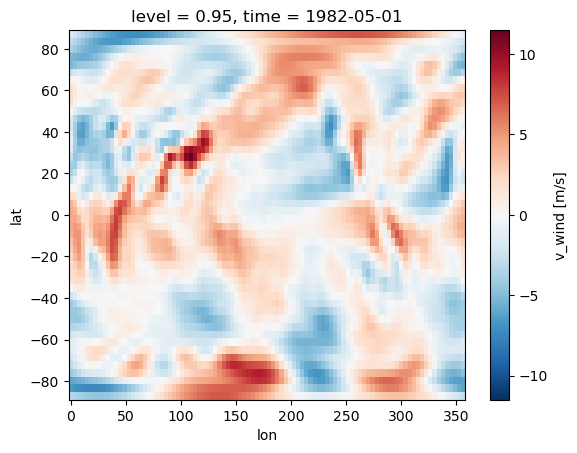

In [9]:
jcm_ds.v_wind.isel(time=1,level=0).plot()

### Compare Winds

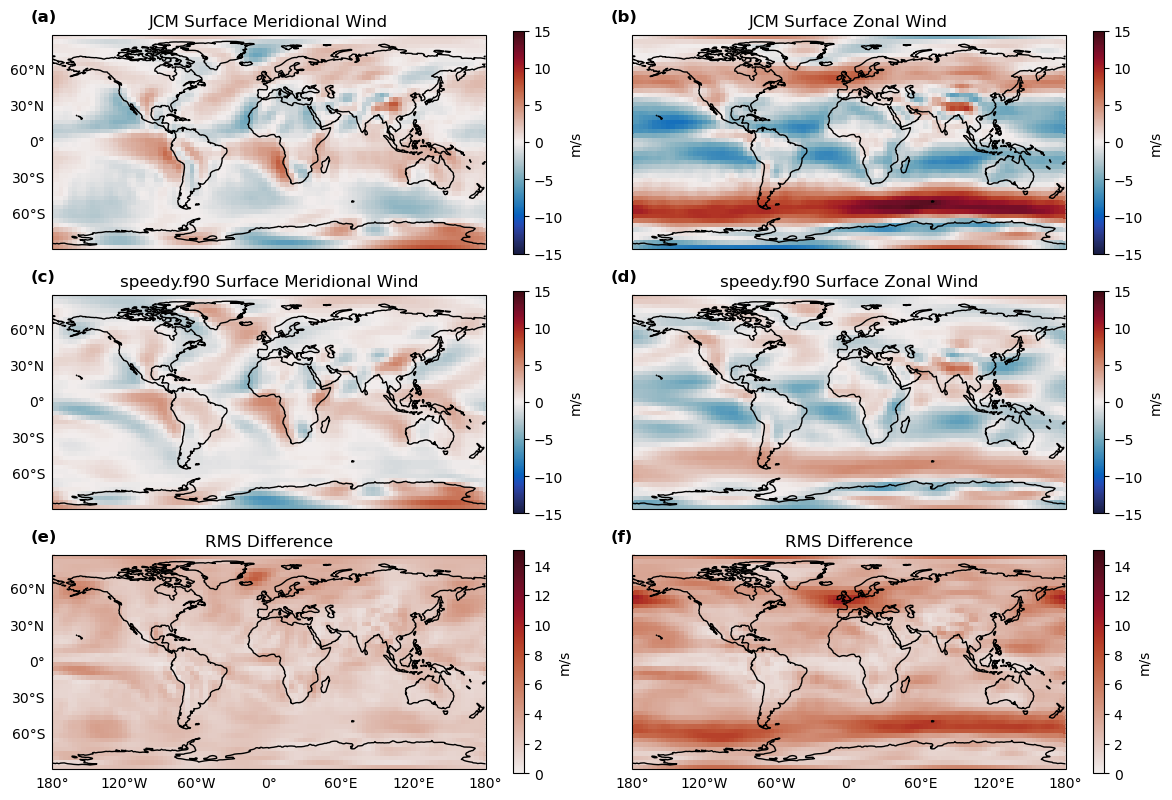

In [10]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()
level = 0

fig, ax = plt.subplots(figsize=(12,8),nrows=3,ncols=2,subplot_kw={'projection': proj})
jcm_ds.v_wind.mean(dim='time').isel(level=level).plot(ax=ax[0,0],cmap=cmo.balance,vmin=-15,vmax=15,cbar_kwargs={'label':'m/s'})
ax[0,0].set_title('JCM Surface Meridional Wind')
ax[0,0].coastlines()
gl = ax[0,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.xlines = False
gl.ylines = False

speedy_ds.v.mean(dim='time').isel(level=level).plot(ax=ax[1,0],cmap=cmo.balance,vmin=-15,vmax=15,cbar_kwargs={'label':'m/s'})
ax[1,0].set_title('speedy.f90 Surface Meridional Wind')
ax[1,0].coastlines()
gl = ax[1,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.xlines = False
gl.ylines = False

diff = np.sqrt(((jcm_ds.v_wind.values - speedy_ds.v.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.v_wind.isel(time=0).coords,dims=jcm_ds.v_wind.isel(time=0).dims)
diff.isel(level=level).plot(ax=ax[2,0],cmap=cmo.amp,vmin=0,vmax=15,cbar_kwargs={'label':'m/s'})
ax[2,0].set_title('RMS Difference')
ax[2,0].coastlines()
gl = ax[2,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False

jcm_ds.u_wind.mean(dim='time').isel(level=level).plot(ax=ax[0,1],cmap=cmo.balance,vmin=-15,vmax=15,cbar_kwargs={'label':'m/s'})
ax[0,1].set_title('JCM Surface Zonal Wind')
ax[0,1].coastlines()

speedy_ds.u.mean(dim='time').isel(level=level).plot(ax=ax[1,1],cmap=cmo.balance,vmin=-15,vmax=15,cbar_kwargs={'label':'m/s'})
ax[1,1].set_title('speedy.f90 Surface Zonal Wind')
ax[1,1].coastlines()

diff = np.sqrt(((jcm_ds.u_wind.values - speedy_ds.u.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.u_wind.isel(time=0).coords,dims=jcm_ds.u_wind.isel(time=0).dims)
diff.isel(level=level).plot(ax=ax[2,1],cmap=cmo.amp,vmin=0,vmax=15,cbar_kwargs={'label':'m/s'})
ax[2,1].set_title('RMS Difference')
ax[2,1].coastlines()
gl = ax[2,1].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = False
gl.xlines = False
gl.ylines = False

axs = ax.ravel()
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for ax, label in zip(axs, labels):
    ax.text(-0.05, 1.12,  label, transform=ax.transAxes,
            ha='left', va='top', fontsize='large', fontweight='bold')

plt.tight_layout()
plt.savefig('jcm_speedy_surface_wind_comparison.png')

In [11]:
diff = np.sqrt(((jcm_ds.v_wind.values - speedy_ds.v.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.u_wind.isel(time=0).coords,dims=jcm_ds.u_wind.isel(time=0).dims)
print(diff.isel(level=level).mean())
diff = np.sqrt(((jcm_ds.u_wind.values - speedy_ds.u.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.u_wind.isel(time=0).coords,dims=jcm_ds.u_wind.isel(time=0).dims)
print(diff.isel(level=level).mean())

<xarray.DataArray ()> Size: 4B
array(2.162203, dtype=float32)
Coordinates:
    level    float32 4B 0.95
    time     datetime64[ns] 8B 1982-04-01
<xarray.DataArray ()> Size: 4B
array(3.4688373, dtype=float32)
Coordinates:
    level    float32 4B 0.95
    time     datetime64[ns] 8B 1982-04-01


In [14]:
jcm_ds.level

<xarray.DataArray 'level' (level: 8)> Size: 32B
array([0.95 , 0.835, 0.685, 0.51 , 0.34 , 0.2  , 0.095, 0.025], dtype=float32)
Coordinates:
  * level    (level) float32 32B 0.95 0.835 0.685 0.51 0.34 0.2 0.095 0.025

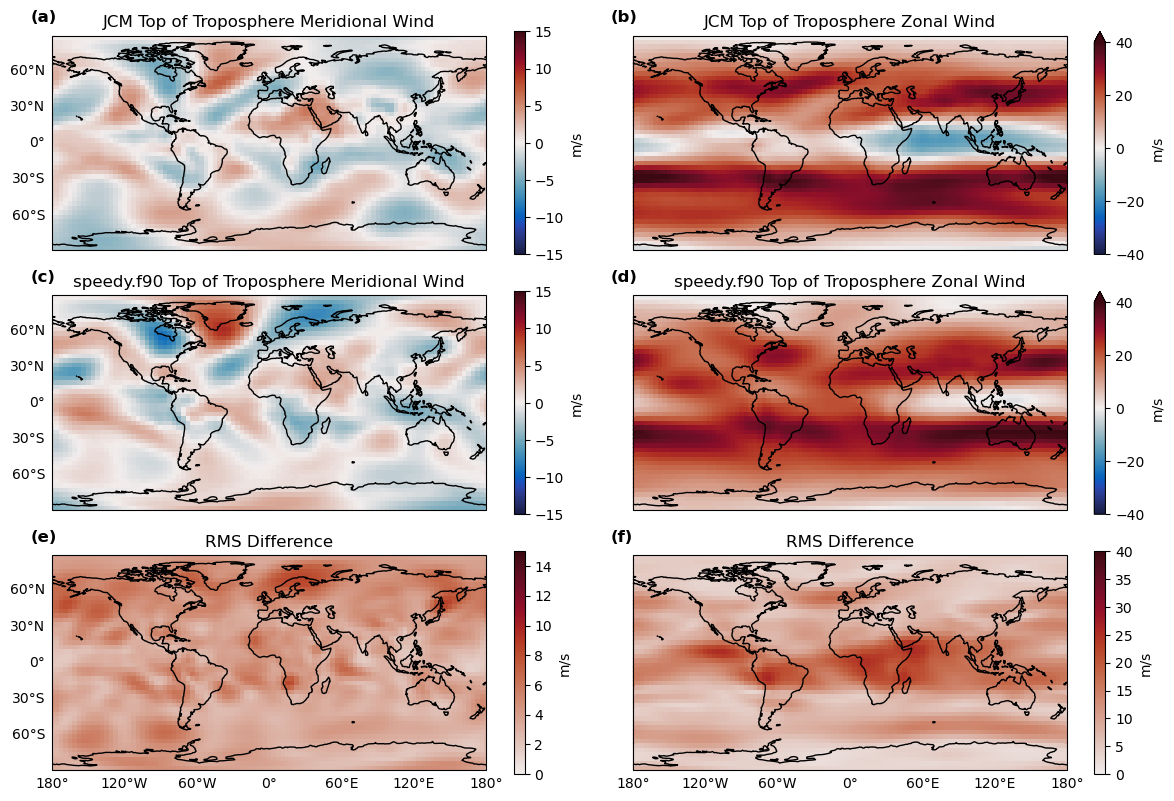

In [15]:
level = 5

fig, ax = plt.subplots(figsize=(12,8),nrows=3,ncols=2,subplot_kw={'projection': proj})
jcm_ds.v_wind.mean(dim='time').isel(level=level).plot(ax=ax[0,0],cmap=cmo.balance,vmin=-15,vmax=15,cbar_kwargs={'label':'m/s'})
ax[0,0].set_title('JCM Top of Troposphere Meridional Wind')
ax[0,0].coastlines()
gl = ax[0,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.xlines = False
gl.ylines = False

speedy_ds.v.mean(dim='time').isel(level=level).plot(ax=ax[1,0],cmap=cmo.balance,vmin=-15,vmax=15,cbar_kwargs={'label':'m/s'})
ax[1,0].set_title('speedy.f90 Top of Troposphere Meridional Wind')
ax[1,0].coastlines()
gl = ax[1,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.xlines = False
gl.ylines = False

diff = np.sqrt(((jcm_ds.v_wind.values - speedy_ds.v.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.v_wind.isel(time=0).coords,dims=jcm_ds.v_wind.isel(time=0).dims)
diff.isel(level=level).plot(ax=ax[2,0],cmap=cmo.amp,vmin=0,vmax=15,cbar_kwargs={'label':'m/s'})
ax[2,0].set_title('RMS Difference')
ax[2,0].coastlines()
gl = ax[2,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False

jcm_ds.u_wind.mean(dim='time').isel(level=level).plot(ax=ax[0,1],cmap=cmo.balance,vmin=-40,vmax=40,cbar_kwargs={'label':'m/s'})
ax[0,1].set_title('JCM Top of Troposphere Zonal Wind')
ax[0,1].coastlines()

speedy_ds.u.mean(dim='time').isel(level=level).plot(ax=ax[1,1],cmap=cmo.balance,vmin=-40,vmax=40,cbar_kwargs={'label':'m/s'})
ax[1,1].set_title('speedy.f90 Top of Troposphere Zonal Wind')
ax[1,1].coastlines()

diff = np.sqrt(((jcm_ds.u_wind.values - speedy_ds.u.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.u_wind.isel(time=0).coords,dims=jcm_ds.u_wind.isel(time=0).dims)
diff.isel(level=level).plot(ax=ax[2,1],cmap=cmo.amp,vmin=0,vmax=40,cbar_kwargs={'label':'m/s'})
ax[2,1].set_title('RMS Difference')
ax[2,1].coastlines()
gl = ax[2,1].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = False
gl.xlines = False
gl.ylines = False

axs = ax.ravel()
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for ax, label in zip(axs, labels):
    ax.text(-0.05, 1.12,  label, transform=ax.transAxes,
            ha='left', va='top', fontsize='large', fontweight='bold')

plt.tight_layout()
plt.savefig('jcm_speedy_troposphere_wind_comparison.png')

In [ ]:
diff = np.sqrt(((jcm_ds.v_wind.values - speedy_ds.v.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.u_wind.isel(time=0).coords,dims=jcm_ds.u_wind.isel(time=0).dims)
print(diff.isel(level=level).mean())
diff = np.sqrt(((jcm_ds.u_wind.values - speedy_ds.u.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.u_wind.isel(time=0).coords,dims=jcm_ds.u_wind.isel(time=0).dims)
print(diff.isel(level=level).mean())

In [ ]:
level = -2

fig, ax = plt.subplots(figsize=(12,8),nrows=3,ncols=2,subplot_kw={'projection': proj})
jcm_ds.v_wind.mean(dim='time').isel(level=level).plot(ax=ax[0,0],cmap=cmo.balance,vmin=-10,vmax=10,cbar_kwargs={'label':'m/s'})
ax[0,0].set_title('JCM Stratosphere Meridional Wind')
ax[0,0].coastlines()
gl = ax[0,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.xlines = False
gl.ylines = False

speedy_ds.v.mean(dim='time').isel(level=level).plot(ax=ax[1,0],cmap=cmo.balance,vmin=-10,vmax=10,cbar_kwargs={'label':'m/s'})
ax[1,0].set_title('speedy.f90 Stratosphere Meridional Wind')
ax[1,0].coastlines()
gl = ax[1,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.xlines = False
gl.ylines = False

diff = np.sqrt(((jcm_ds.v_wind.values - speedy_ds.v.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.v_wind.isel(time=0).coords,dims=jcm_ds.v_wind.isel(time=0).dims)
diff.isel(level=level).plot(ax=ax[2,0],cmap=cmo.amp,vmin=0,vmax=10,cbar_kwargs={'label':'m/s'})
ax[2,0].set_title('RMS Difference')
ax[2,0].coastlines()
gl = ax[2,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False

jcm_ds.u_wind.mean(dim='time').isel(level=level).plot(ax=ax[0,1],cmap=cmo.balance,vmin=-40,vmax=40,cbar_kwargs={'label':'m/s'})
ax[0,1].set_title('JCM Stratosphere Zonal Wind')
ax[0,1].coastlines()

speedy_ds.u.mean(dim='time').isel(level=level).plot(ax=ax[1,1],cmap=cmo.balance,vmin=-40,vmax=40,cbar_kwargs={'label':'m/s'})
ax[1,1].set_title('speedy.f90 Stratosphere Zonal Wind')
ax[1,1].coastlines()

diff = np.sqrt(((jcm_ds.u_wind.values - speedy_ds.u.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.u_wind.isel(time=0).coords,dims=jcm_ds.u_wind.isel(time=0).dims)
diff.isel(level=level).plot(ax=ax[2,1],cmap=cmo.amp,vmin=0,vmax=40,cbar_kwargs={'label':'m/s'})
ax[2,1].set_title('RMS Difference')
ax[2,1].coastlines()
gl = ax[2,1].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = False
gl.xlines = False
gl.ylines = False

axs = ax.ravel()
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for ax, label in zip(axs, labels):
    ax.text(-0.05, 1.12,  label, transform=ax.transAxes,
            ha='left', va='top', fontsize='large', fontweight='bold')

plt.tight_layout()
plt.savefig('jcm_speedy_stratosphere_wind_comparison.png')

In [ ]:
diff = np.sqrt(((jcm_ds.v_wind.values - speedy_ds.v.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.u_wind.isel(time=0).coords,dims=jcm_ds.u_wind.isel(time=0).dims)
print(diff.isel(level=level).mean())
diff = np.sqrt(((jcm_ds.u_wind.values - speedy_ds.u.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.u_wind.isel(time=0).coords,dims=jcm_ds.u_wind.isel(time=0).dims)
print(diff.isel(level=level).mean())

In [ ]:
level = 0

fig, ax = plt.subplots(figsize=(12,8),nrows=3,ncols=2,subplot_kw={'projection': proj})
jcm_ds.temperature.mean(dim='time').isel(level=level).plot(ax=ax[0,0],cmap=cmo.thermal,vmin=-40,vmax=30,cbar_kwargs={'label':'C'})
ax[0,0].set_title('JCM Surface Temperature')
ax[0,0].coastlines()
gl = ax[0,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.xlines = False
gl.ylines = False

speedy_ds.t.mean(dim='time').isel(level=level).plot(ax=ax[1,0],cmap=cmo.thermal,vmin=-40,vmax=30,cbar_kwargs={'label':'C'})
ax[1,0].set_title('speedy.f90 Surface Temperature')
ax[1,0].coastlines()
gl = ax[1,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.xlines = False
gl.ylines = False

diff = np.sqrt(((jcm_ds.temperature.values - speedy_ds.t.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.temperature.isel(time=0).coords,dims=jcm_ds.temperature.isel(time=0).dims)
diff.isel(level=level).plot(ax=ax[2,0],cmap=cmo.amp,vmin=0,vmax=20,cbar_kwargs={'label':'C'})
ax[2,0].set_title('RMS Difference')
ax[2,0].coastlines()
gl = ax[2,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False

jcm_ds.specific_humidity.mean(dim='time').isel(level=level).plot(ax=ax[0,1],cmap=cmo.haline,vmin=0,vmax=20,cbar_kwargs={'label':'g/kg'})
ax[0,1].set_title('JCM Surface Specific Humidity')
ax[0,1].coastlines()

speedy_ds.q.mean(dim='time').isel(level=level).plot(ax=ax[1,1],cmap=cmo.haline,vmin=0,vmax=20,cbar_kwargs={'label':'g/kg'})
ax[1,1].set_title('speedy.f90 Surface Specific Humidity')
ax[1,1].coastlines()

diff = np.sqrt(((jcm_ds.specific_humidity.values - speedy_ds.q.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.specific_humidity.isel(time=0).coords,dims=jcm_ds.specific_humidity.isel(time=0).dims)
diff.isel(level=level).plot(ax=ax[2,1],cmap=cmo.amp,vmin=0,vmax=10,cbar_kwargs={'label':'g/kg'})
ax[2,1].set_title('RMS Difference')
ax[2,1].coastlines()
gl = ax[2,1].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = False
gl.xlines = False
gl.ylines = False

axs = ax.ravel()
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for ax, label in zip(axs, labels):
    ax.text(-0.05, 1.12,  label, transform=ax.transAxes,
            ha='left', va='top', fontsize='large', fontweight='bold')

plt.tight_layout()
plt.savefig('jcm_speedy_surface_temp_humidity_comparison.png')

In [ ]:
diff = np.sqrt(((jcm_ds.specific_humidity.values - speedy_ds.q.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.specific_humidity.isel(time=0).coords,dims=jcm_ds.specific_humidity.isel(time=0).dims)
print(diff.isel(level=level).mean())
diff = np.sqrt(((jcm_ds.temperature.values - speedy_ds.t.values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds.temperature.isel(time=0).coords,dims=jcm_ds.temperature.isel(time=0).dims)
print(diff.isel(level=level).mean())

In [ ]:
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
proj = ccrs.PlateCarree()

fig,ax = plt.subplots(figsize=(18,8),nrows=3,ncols=3,subplot_kw={'projection': proj})
jcm_ds['shortwave_rad.cloudstr'].mean(dim='time').plot(ax=ax[0,0],cmap=cmo.haline,vmin=0,vmax=0.4,cbar_kwargs={'label':'Fraction'})
ax[0,0].coastlines()
ax[0,0].set_title('JCM Stratiform Cloud Cover')
ax[0,0].set_xlabel('')
ax[0,0].set_ylabel('Latitude')
gl = ax[0,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.xlines = False
gl.ylines = False

# speedy cloudstr
speedy_clouds['cloudstr'].mean(dim='time').plot(ax=ax[1,0],cmap=cmo.haline,vmin=0,vmax=0.4,cbar_kwargs={'label':'Fraction'})
ax[1,0].coastlines()
ax[1,0].set_title('speedy.f90 Stratiform Cloud Cover')
ax[1,0].set_xlabel('')
ax[1,0].set_ylabel('Latitude')
gl = ax[1,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.xlines = False
gl.ylines = False

# RMSD Cloudstr
diff = np.sqrt(((jcm_ds['shortwave_rad.cloudstr'].values - speedy_clouds['cloudstr'].values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds['shortwave_rad.cloudstr'].isel(time=0).coords,dims=jcm_ds['shortwave_rad.cloudstr'].isel(time=0).dims)
diff.plot(ax=ax[2,0],cmap=cmo.amp,vmin=0,vmax=0.4,cbar_kwargs={'label':'Fraction'})
ax[2,0].set_title('RMS Difference')
ax[2,0].coastlines()
gl = ax[2,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False

# JCM precnv
jcm_ds['convection.precnv'].mean(dim='time').plot(ax=ax[0,1],cmap=cmo.matter,vmin=0,vmax=0.2,cbar_kwargs={'label':'$g/m^2/s$'})
ax[0,1].coastlines()
ax[0,1].set_title('JCM Precip From Convection')
ax[0,1].set_xlabel('')
ax[0,1].set_ylabel('Latitude')
gl = ax[0,1].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = False
gl.xlines = False
gl.ylines = False

# speedy precnv
speedy_clouds['precnv'].mean(dim='time').plot(ax=ax[1,1],cmap=cmo.matter,vmin=0,vmax=0.2,cbar_kwargs={'label':'$g/m^2/s$'})
ax[1,1].coastlines()
ax[1,1].set_title('speedy.f90 Precip From Convection')
ax[1,1].set_xlabel('')
ax[1,1].set_ylabel('Latitude')
gl = ax[1,1].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = False
gl.xlines = False
gl.ylines = False

# RMSD precnv
diff = np.sqrt(((jcm_ds['convection.precnv'].values - speedy_clouds['precnv'].values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds['convection.precnv'].isel(time=0).coords,dims=jcm_ds['convection.precnv'].isel(time=0).dims)
diff.plot(ax=ax[2,1],cmap=cmo.amp,vmin=0,vmax=0.2,cbar_kwargs={'label':'$g/m^2/s$'})
ax[2,1].set_title('RMS Difference')
ax[2,1].coastlines()
gl = ax[2,1].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = False
gl.xlines = False
gl.ylines = False

jcm_ds['condensation.precls'].mean(dim='time').plot(ax=ax[0,2],cmap=cmo.dense,vmin=0,vmax=0.1,cbar_kwargs={'label':'$g/m^2/s$'})
ax[0,2].set_title('JCM Precip From Large Scale Condensation')
ax[0,2].set_xlabel('Longitude')
ax[0,2].set_ylabel('Latitude')
ax[0,2].coastlines()
gl = ax[0,2].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = False
gl.xlines = False
gl.ylines = False

speedy_clouds['precls'].mean(dim='time').plot(ax=ax[1,2],cmap=cmo.dense,vmin=0,vmax=0.1,cbar_kwargs={'label':'$g/m^2/s$'})
ax[1,2].set_title('speedy.f90 Precip From Large Scale Condensation')
ax[1,2].set_xlabel('Longitude')
ax[1,2].set_ylabel('Latitude')
ax[1,2].coastlines()
gl = ax[1,2].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = False
gl.xlines = False
gl.ylines = False

# RMSD precls
diff = np.sqrt(((jcm_ds['condensation.precls'].values - speedy_clouds['precls'].values)**2).mean(axis=0))
diff = xr.DataArray(diff,coords=jcm_ds['condensation.precls'].isel(time=0).coords,dims=jcm_ds['condensation.precls'].isel(time=0).dims)
diff.plot(ax=ax[2,2],cmap=cmo.amp,vmin=0,vmax=0.1,cbar_kwargs={'label':'$g/m^2/s$'})
ax[2,2].set_title('RMS Difference')
ax[2,2].coastlines()
gl = ax[2,2].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = False
gl.xlines = False
gl.ylines = False

axs = ax.ravel()
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)','(g)', '(h)', '(i)']

for ax, label in zip(axs, labels):
    ax.text(-0.05, 1.12,  label, transform=ax.transAxes,
            ha='left', va='top', fontsize='large', fontweight='bold')

plt.tight_layout()
plt.savefig('jcm_speedy_clouds_precip.png',dpi=300)

In [ ]:
level = 0

fig, ax = plt.subplots(figsize=(12,8),nrows=3,ncols=2,subplot_kw={'projection': proj})
jcm_ds.temperature.mean(dim='time').isel(level=level).plot(ax=ax[0,0],cmap=cmo.thermal,vmin=-40,vmax=30,cbar_kwargs={'label':'C'})
ax[0,0].set_title('JCM Surface Temperature')
ax[0,0].coastlines()
gl = ax[0,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.xlines = False
gl.ylines = False

speedy_ds.t.mean(dim='time').isel(level=level).plot(ax=ax[1,0],cmap=cmo.thermal,vmin=-40,vmax=30,cbar_kwargs={'label':'C'})
ax[1,0].set_title('speedy.f90 Surface Temperature')
ax[1,0].coastlines()
gl = ax[1,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.xlines = False
gl.ylines = False

diff = (jcm_ds.temperature.mean(dim='time').values - speedy_ds.t.mean(dim='time').values)/speedy_ds.t.mean(dim='time').values * 100
diff = xr.DataArray(diff,coords=jcm_ds.temperature.isel(time=0).coords,dims=jcm_ds.temperature.isel(time=0).dims)
diff.isel(level=level).plot(ax=ax[2,0],cmap=cmo.balance,vmin=-100,vmax=100,cbar_kwargs={'label':'C'})
ax[2,0].set_title('% Difference')
ax[2,0].coastlines()
gl = ax[2,0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False

jcm_ds.specific_humidity.mean(dim='time').isel(level=level).plot(ax=ax[0,1],cmap=cmo.haline,vmin=0,vmax=20,cbar_kwargs={'label':'g/kg'})
ax[0,1].set_title('JCM Surface Specific Humidity')
ax[0,1].coastlines()

speedy_ds.q.mean(dim='time').isel(level=level).plot(ax=ax[1,1],cmap=cmo.haline,vmin=0,vmax=20,cbar_kwargs={'label':'g/kg'})
ax[1,1].set_title('speedy.f90 Surface Specific Humidity')
ax[1,1].coastlines()

diff = (jcm_ds.specific_humidity.mean(dim='time').values - speedy_ds.q.mean(dim='time').values)/speedy_ds.q.mean(dim='time').values * 100
diff = xr.DataArray(diff,coords=jcm_ds.specific_humidity.isel(time=0).coords,dims=jcm_ds.specific_humidity.isel(time=0).dims)
diff.isel(level=level).plot(ax=ax[2,1],cmap=cmo.balance,vmin=-100,vmax=100,cbar_kwargs={'label':'g/kg'})
ax[2,1].set_title('% Difference')
ax[2,1].coastlines()
gl = ax[2,1].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = False
gl.xlines = False
gl.ylines = False

axs = ax.ravel()
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for ax, label in zip(axs, labels):
    ax.text(-0.05, 1.12,  label, transform=ax.transAxes,
            ha='left', va='top', fontsize='large', fontweight='bold')


plt.tight_layout()
plt.savefig('jcm_speedy_surface_temp_humidity_comparison_percent.png')